# Clustering
In contrast to supervised machine learning, unsupervised learning is used when there is no "ground truth" from which to train and validate label predictions. The most common form of unsupervised learning is clustering, which is simllar conceptually to classification, except that the the training data does not include known values for the class label to be predicted.

#### Use cases
- Marketing organization might want to separate customers into distinct segments, and then investigate how those segments exhibit different purchasing behaviors.
- First step towards creating a classification model. You start by identifying distinct groups of data points, and then assign class labels to those clusters. You can then use this labelled data to train a classification model.

In [2]:
import pandas as pd

# load the training dataset
# !wget https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/ml-basics/seeds.csv
data = pd.read_csv('../../DATA/seeds.csv')

# Display a random sample of 10 observations (just the features)
features = data[data.columns[0:6]]
features.sample(4)

,area,perimeter,compactness,kernel_length,kernel_width,asymmetry_coefficient
123,18.43,15.97,0.9077,5.980,3.771,2.984
76,17.32,15.91,0.8599,6.064,3.403,3.824
46,15.36,14.76,0.8861,5.701,3.393,1.367
47,14.99,14.56,0.8883,5.570,3.377,2.958


As you can see, the dataset contains six data points (or features) for each instance (observation) of a seed. So you could interpret these as coordinates that describe each instance's location in six-dimensional space.

- In order to visualize if there are any clusters in the data, we may have to bring the N-dimensional data into a 2-dimensional.
- Now, of course six-dimensional space is difficult to visualise in a three-dimensional world, or on a two-dimensional plot; so we'll take advantage of a mathematical technique called Principal Component Analysis (PCA) to analyze the relationships between the features and summarize each observation as coordinates for two principal components 

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# Normalize the numeric features so they're on the same scale
scaled_features = MinMaxScaler().fit_transform(features[data.columns[0:6]])

# Get two principal components
pca = PCA(n_components=2).fit(scaled_features)
features_2d = pca.transform(scaled_features)
features_2d[0:4]

array([[ 0.11883593, -0.09382469],
       [ 0.0696878 , -0.31077233],
       [-0.03499184, -0.37044705],
       [-0.06582089, -0.36365235]])

Now that we have the data points translated to two dimensions, we can visualize them in a plot:

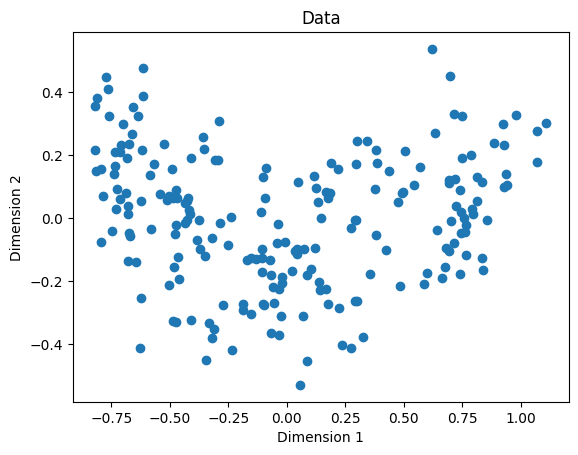

In [4]:
import matplotlib.pyplot as plt

%matplotlib inline

plt.scatter(features_2d[:,0],features_2d[:,1])
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.title('Data')
plt.show()

- Here we can spot 2 or 3 clusters. Is this correct? Let's see what KMeans thinks :)

### A metric often used to measure this tightness is the within cluster sum of squares (WCSS), with lower values meaning that the data points are closer. You can then plot the WCSS for each model.

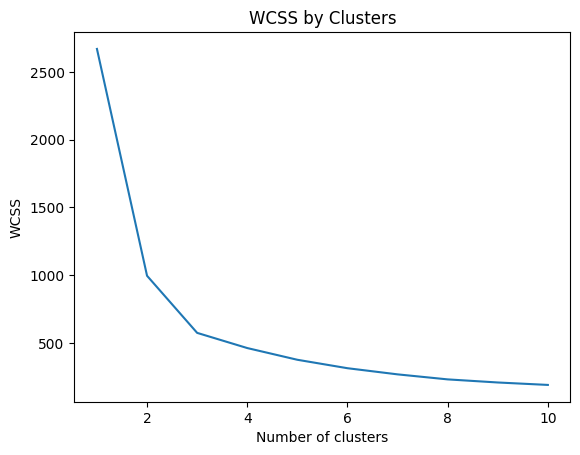

In [5]:
#importing the libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
%matplotlib inline

# Create 10 models with 1 to 10 clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i)
    # Fit the data points
    kmeans.fit(features.values)
    # Get the WCSS (inertia) value
    wcss.append(kmeans.inertia_)
    
#Plot the WCSS values onto a line graph
plt.plot(range(1, 11), wcss)
plt.title('WCSS by Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

- By following the elbow rule, we can identify that with only 2 clusters, the Within-Cluster-Sum-of-Squares distance (WCSS) decreases considerably.
- When adding one more cluster, so 3, the WCSS falls again from 1000 to half.
- We do not see a further significant reduction of WCSS by adding more groups.
- Of course, with 10 groups the WCSS reaches very low values, but it does not mean, 10 clusters are more representative of the actual data.

# K-Means

The algorithm we used to create our test clusters is *K-Means*. This is a commonly used clustering algorithm that separates a dataset into *K* clusters of equal variance. The number of clusters, *K*, is user defined. The basic algorithm has the following steps:

1. A set of K centroids are randomly chosen.
2. Clusters are formed by assigning the data points to their closest centroid.
3. The means of each cluster is computed and the centroid is moved to the mean.
4. Steps 2 and 3 are repeated until a stopping criteria is met. Typically, the algorithm terminates when each new iteration results in negligable movement of centroids and the clusters become static.
5. When the clusters stop changing, the algorithm has *converged*, defining the locations of the clusters - note that the random starting point for the centroids means that re-running the algorithm could result in slightly different clusters, so training usually involves multiple iterations, reinitializing the centroids each time, and the model with the best WCSS is selected.

Let's try using K-Means on our seeds data with a K value of 3.

In [8]:
from sklearn.cluster import KMeans

# Create a model based on 3 centroids, since with the elbow method we saw that 3 may be a good estimate.
model = KMeans(n_clusters=3, init='k-means++', n_init=100, max_iter=1000)


# PARAMETERS:
# - n_init   : Min number of iterations the Kmean runs with different random centroids.
# - max_iter : Max num of iterations improving the centroids for a single KMean run.


# Fit to the data and predict the cluster assignments for each data point
km_clusters = model.fit_predict(features.values)

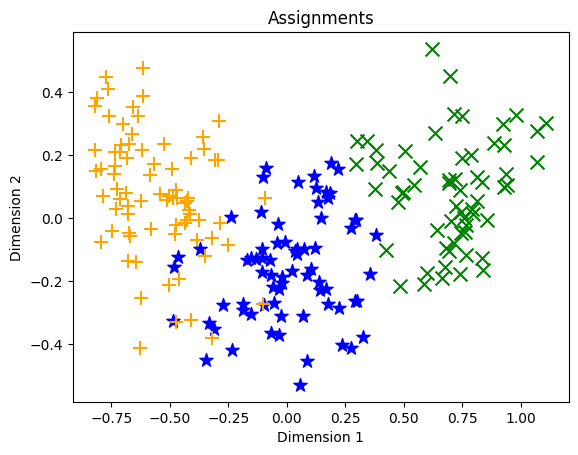

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_clusters(samples, clusters):
    col_dic = {0:'blue',1:'green',2:'orange'}
    mrk_dic = {0:'*',1:'x',2:'+'}
    colors = [col_dic[x] for x in clusters]
    markers = [mrk_dic[x] for x in clusters]
    for sample in range(len(clusters)):
        plt.scatter(samples[sample][0], samples[sample][1], color = colors[sample], marker=markers[sample], s=100)
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('Assignments')
    plt.show()

plot_clusters(features_2d, km_clusters)

### In this example, we already knew the actual labels. Let's evaluate then our KMeans.

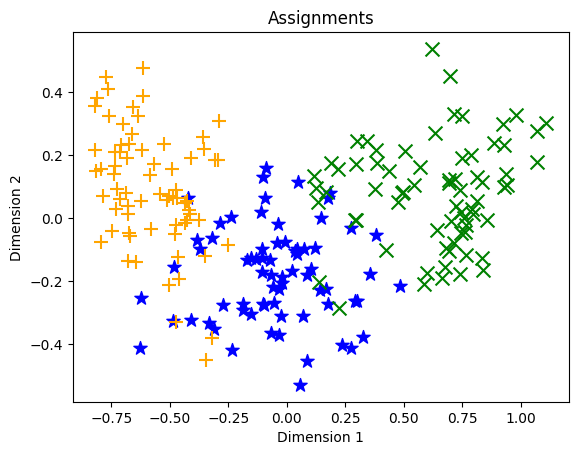

In [10]:
seed_species = data[data.columns[7]]
plot_clusters(features_2d, seed_species.values)